# Exercício 1

Selecione uma rede com estrutura de comunidades clara e que tenha um
tamanho razoável, evitando redes muito pequenas. Certifique-se de que exista uma partição de
referência para a rede escolhida. Utilize ao menos quatro métodos de detecção de
comunidades, entre os discutidos ou mencionados em aula.

Para cada método:

1. Encontre a partição obtida, exibindo a divisão dos nós em grupos.
2. Utilize um método de visualização de redes para ilustrar as divisões em grupos.

Além disso, realize as seguintes análises:

- Calcule a modularidade para cada subdivisão gerada pelos algoritmos.
- Calcule a similaridade entre as partições obtidas por cada par de algoritmos,
identificando os mais similares e os mais diferentes.
- Determine qual dos métodos produz a melhor partição em relação à partição de
referência. É possível identificar visualmente que o melhor algoritmo gera visualmente o
melhor resultado de acordo com a partição de referência?

Nodes:  198
Edges:  2742
Modularity:  0.445
Quality:  (0.7782640408460978, 0.7611649489822079)


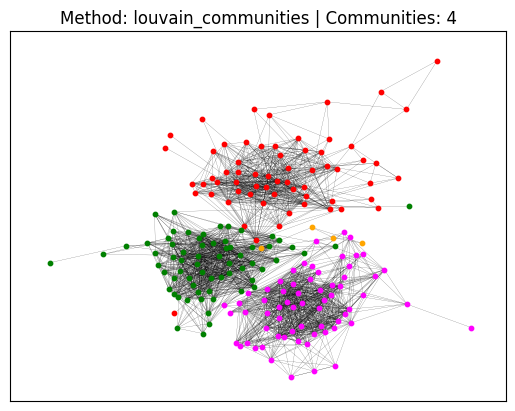

Modularity:  0.439
Quality:  (0.7793581327498177, 0.7580884992052505)


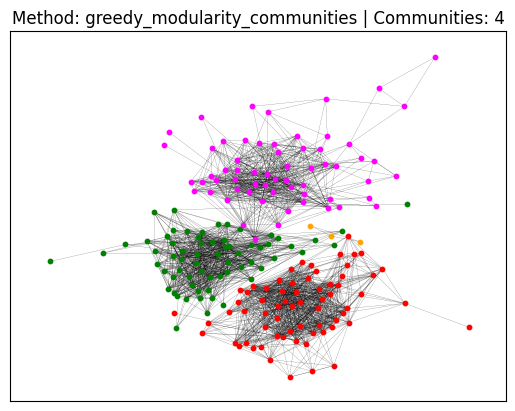

Modularity:  0.282
Quality:  (0.9456601021152443, 0.5544275239706712)


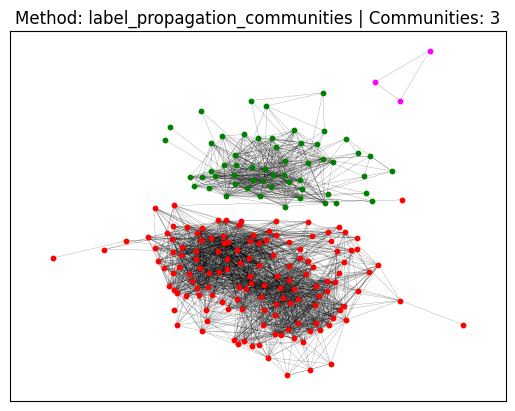

Modularity:  0.282
Quality:  (0.9467541940189642, 0.5461211095728862)


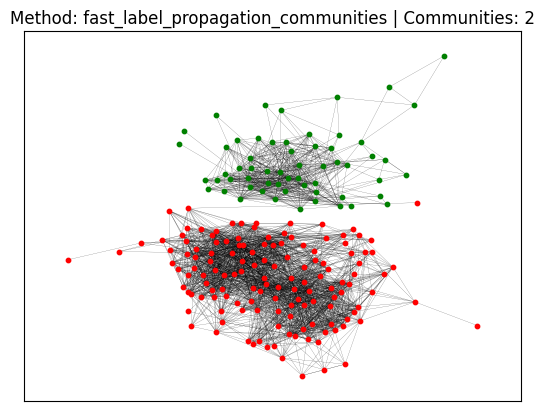

In [37]:
import random

import networkx as nx
from networkx.algorithms.community import modularity
from networkx.algorithms.community.quality import partition_quality

from matplotlib import pyplot as plt


random.seed(1)

def read_network(fname: str) -> nx.Graph:
    return nx.read_edgelist(fname)

def node_label_community(partition, node):
    for i, community in enumerate(partition):
        if node in community:
            return i
    return -1

def community_labels(G, partition):
    return [
        node_label_community(partition, n)
        for n in G_jazz.nodes
    ]

def draw_communities(G: nx.Graph, community_detection=nx.community.louvain_communities):
    communities = list(community_detection(G))
    sub_graphs = [G.subgraph(community) for community in communities]
    print("Modularity: ", round(modularity(G, communities), ndigits=3))
    print("Quality: ", partition_quality(G, communities))
    
    pos = nx.kamada_kawai_layout(G) # kawai is better than spring layout in that case
    
    node_colors = ["red", "green", "magenta", "orange", "yellow", "black", "cyan"]
    plt.figure()
    plt.title(f"Method: {community_detection.__name__} | Communities: {len(communities)}")
    for c, s in zip(node_colors, sub_graphs):
        nx.draw_networkx(s, with_labels=False, width=0.1, node_size=10, pos=pos, node_color=c)

    plt.show()
    return community_labels(G, communities)

def describe_network(G: nx.Graph):
    print("Nodes: ", len(G))
    print("Edges: ", len(G.edges))

def draw_all(G):
    louvain = draw_communities(G, community_detection=nx.community.louvain_communities)
    greedy = draw_communities(G, community_detection=nx.community.greedy_modularity_communities)
    labelp = draw_communities(G, community_detection=nx.community.label_propagation_communities)
    fast_labelp = draw_communities(G, community_detection=nx.community.fast_label_propagation_communities)

G_jazz = read_network("networks/jazz.txt")
describe_network(G_jazz)
draw_all(G_jazz)

In [25]:
from sklearn.metrics import normalized_mutual_info_score

comparison = [
    ("louvain x greedy", louvain, greedy),
    ("louvain x label-propagation", louvain, labelp),
    ("louvain x fast-label-propagation", louvain, fast_labelp),
    ("greedy x label-propagation", greedy, fast_labelp),
    ("greedy x fast-label-propagation", greedy, fast_labelp),
    ("label-propagation x fast-label-propagation", labelp, fast_labelp),
]

max_pad = max([len(k[0]) for k in comparison])

for name, c1, c2 in comparison:
    mutual_score = round(normalized_mutual_info_score(c1, c2), ndigits=2)
    print(name.rjust(max_pad), f"\t{mutual_score}")


                          louvain x greedy 	0.84
               louvain x label-propagation 	0.58
          louvain x fast-label-propagation 	0.6
                greedy x label-propagation 	0.62
           greedy x fast-label-propagation 	0.62
label-propagation x fast-label-propagation 	0.95


# Exercício 2

Selecione uma rede relativamente pequena, com uma estrutura de comunidades
conhecida. Utilize pelo menos quatro métodos de detecção de comunidades discutidos ou
mencionados em aula.

Remova aleatoriamente `x%` das arestas da rede e, em seguida, avalie a qualidade das
partições geradas por cada algoritmo. Analise como a remoção de arestas impacta a qualidade
das partições para cada método.

Por fim, identifique qual dos algoritmos se mostra mais robusto diante da remoção das arestas.
Repita a análise para a modularidade.

Modularity:  0.457
Quality:  (0.7963541666666667, 0.744193201045993)


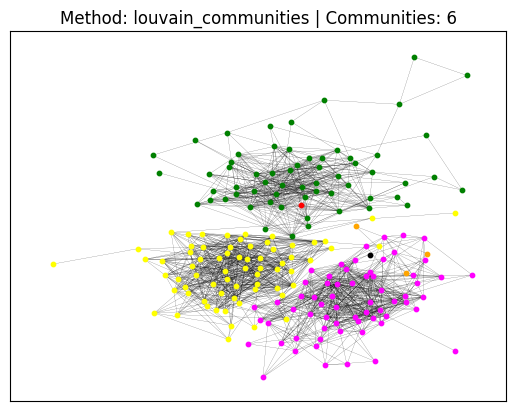

Modularity:  0.452
Quality:  (0.7911458333333333, 0.7433728144388043)


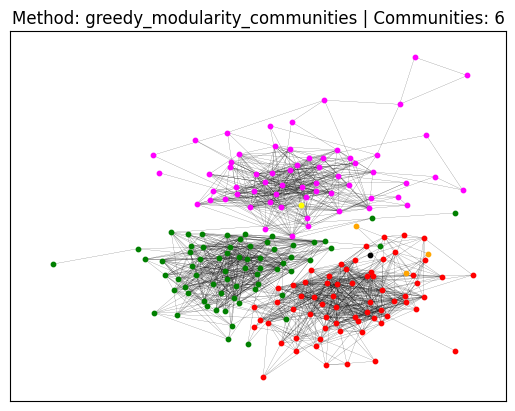

Modularity:  0.288
Quality:  (0.9463541666666667, 0.5268932984669026)


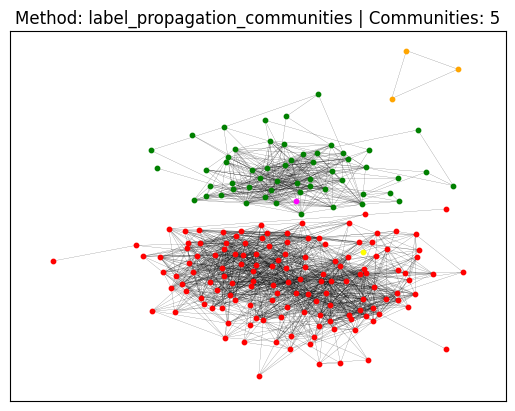

Modularity:  0.427
Quality:  (0.8005208333333333, 0.7290160488130031)


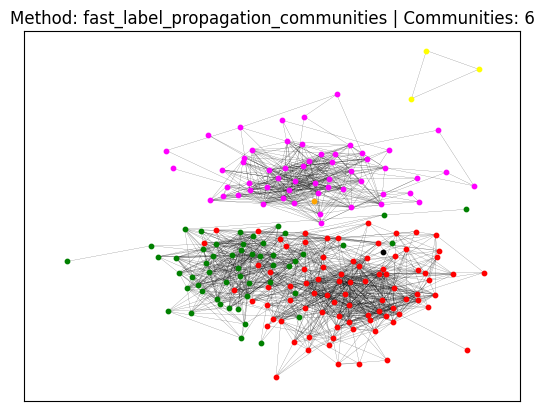

In [43]:
def remove_percentage_of_edges(graph, percentage):
    # Calculate the number of edges to remove
    num_edges_to_remove = int(len(graph.edges) * (percentage / 100))
    
    # Get a list of all edges in the graph
    edges = list(graph.edges)
    
    # Randomly select edges to remove
    edges_to_remove = random.sample(edges, num_edges_to_remove)
    
    # Remove the selected edges from the graph
    graph.remove_edges_from(edges_to_remove)
    
    return graph

draw_all(remove_percentage_of_edges(read_network("networks/jazz.txt"), 30))